In [17]:

using PKAssetPrices.Dynamic: DynamicModel, DiscreteTime, DynamicParametrization, solve_model, @model
using PKAssetPrices
using CairoMakie

In [2]:
sol_baseline =  solve_model(Dynamic.DynQconAPLevelChange2)

PKAssetPrices.Dynamic.DynamicSolution{PKAssetPrices.Dynamic.var"#77#78", PKAssetPrices.Dynamic.var"#79#80", Float64, Vector{Float64}}(DynamicParametrization{PKAssetPrices.Dynamic.var"#77#78", PKAssetPrices.Dynamic.var"#79#80", Float64, Vector{Float64}}(DynamicModel{PKAssetPrices.Dynamic.var"#77#78", PKAssetPrices.Dynamic.var"#79#80"}(DiscreteTime([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0  …  91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0]), PKAssetPrices.Dynamic.DynVar[PKAssetPrices.Dynamic.DynVar(:Y, "Output"), PKAssetPrices.Dynamic.DynVar(:ND, "Non debt-financed demand"), PKAssetPrices.Dynamic.DynVar(:D, "debt-financed demand"), PKAssetPrices.Dynamic.DynVar(:i, "policy rate"), PKAssetPrices.Dynamic.DynVar(:r, "interest rate"), PKAssetPrices.Dynamic.DynVar(:P, "price level"), PKAssetPrices.Dynamic.DynVar(:dL, "change in loans"), PKAssetPrices.Dynamic.DynVar(:dM, "change in money"), PKAssetPrices.Dynamic.DynVar(:dR, "change in reserves"), PKAssetPrices.Dynamic.DynV

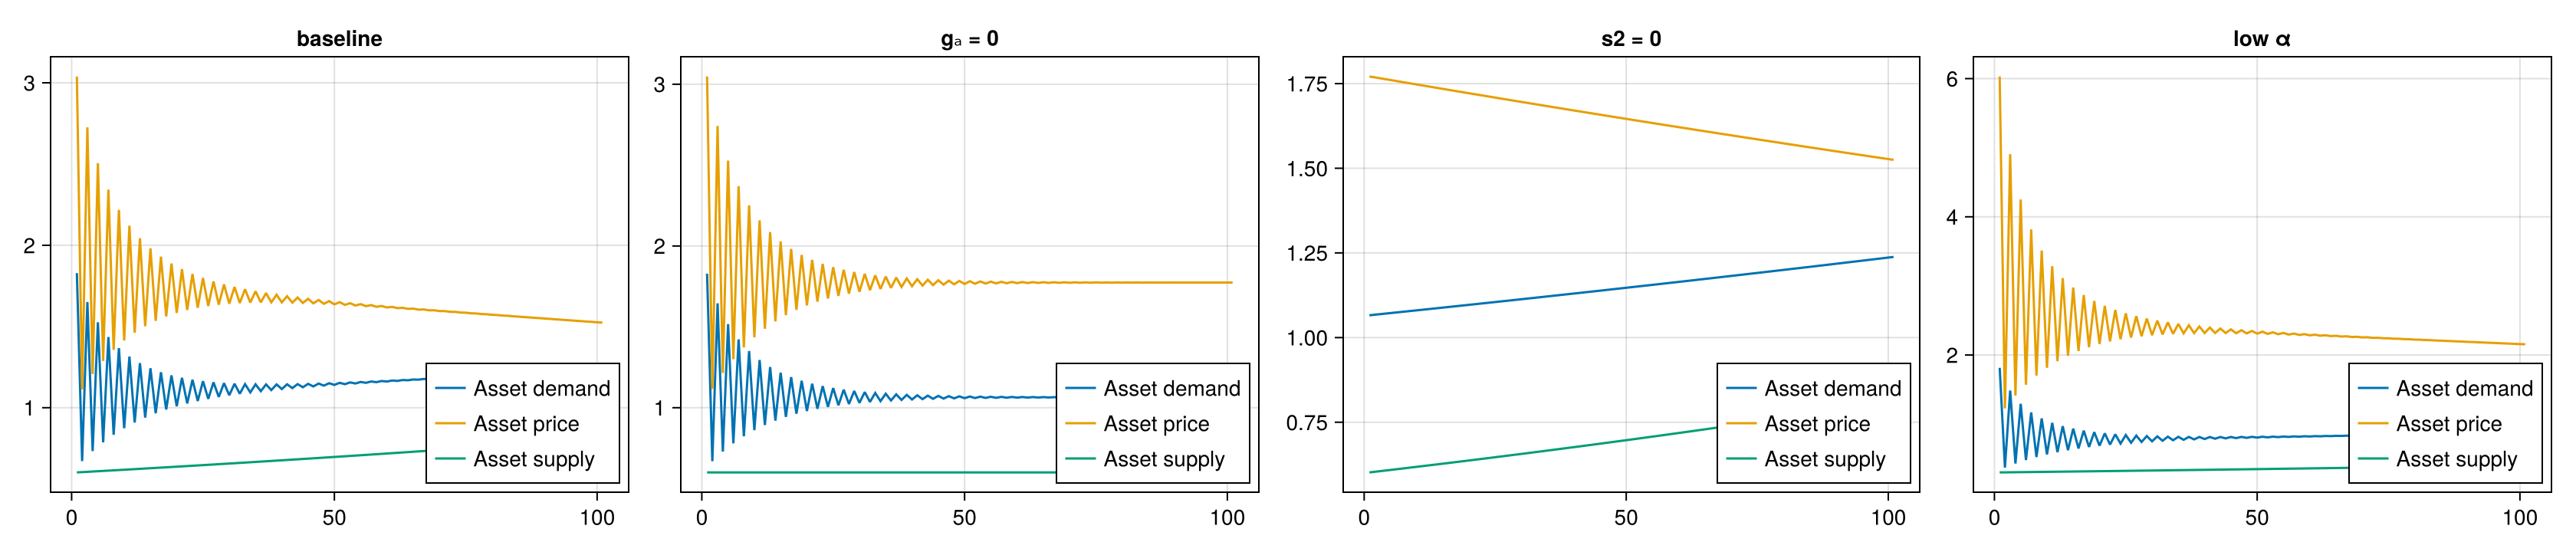

In [21]:
baseline = run_dynq_case()

cases = [
    baseline,
    run_dynq_case(label = "gₐ = 0", gₐ_ = 0.0),
    run_dynq_case(label = "s2 = 0", s2_ = 0.0),
    run_dynq_case(label = "low α", α_ = 0.05),
]

compare_dynq_cases(cases; vars = [:AD, :AP, :AS])
# compare_dynq_cases(cases; vars = [:Y, :W, :N, :U], ylabel = "Real side", sharey = true)


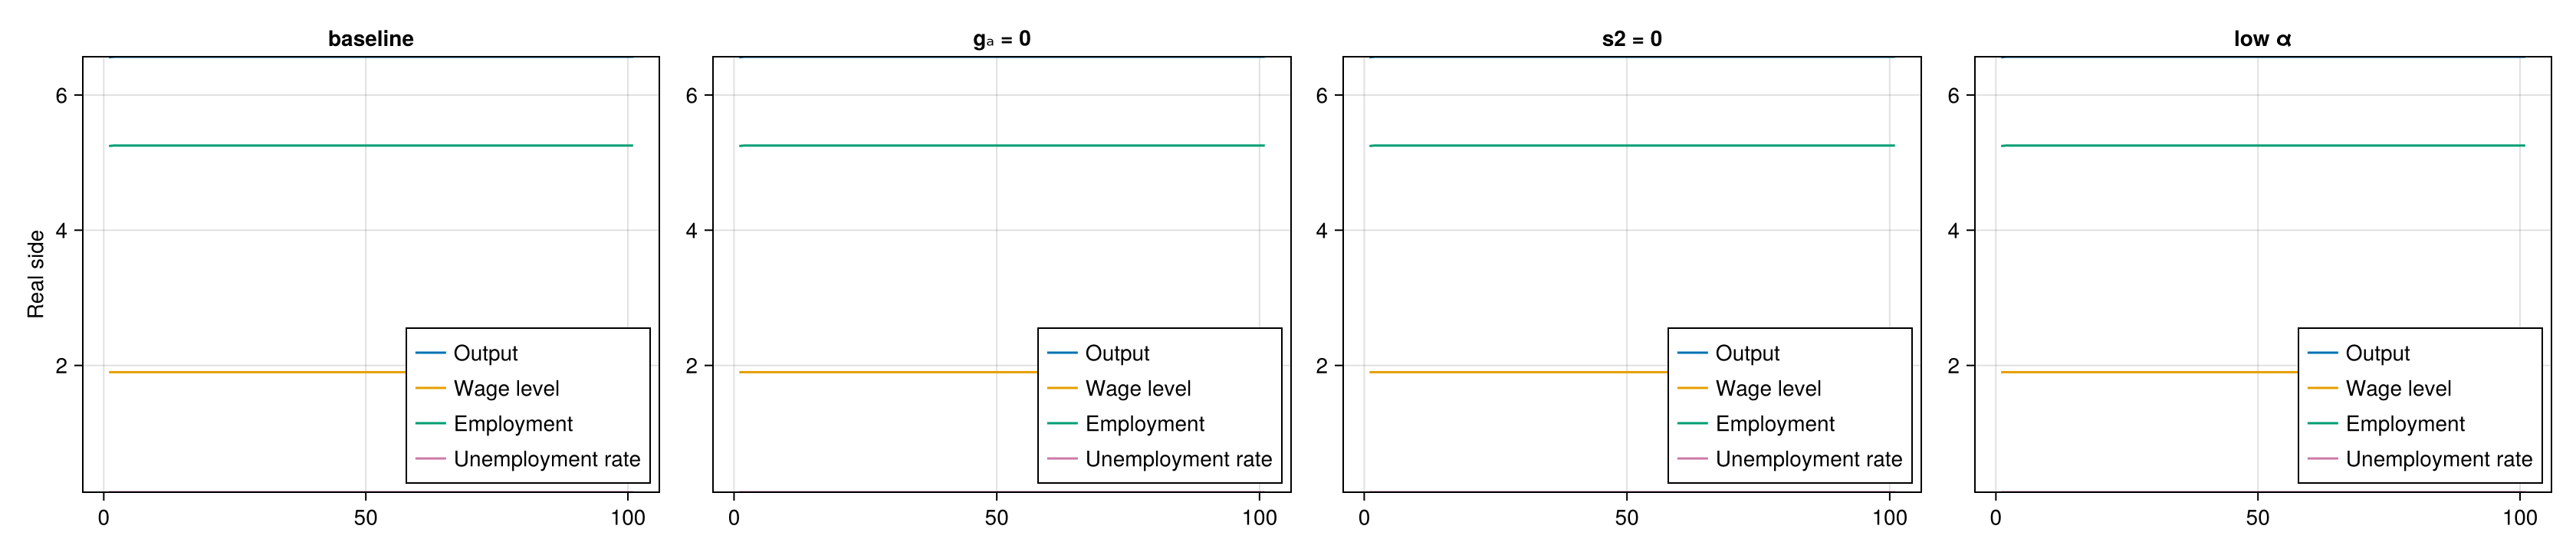

In [20]:
compare_dynq_cases(cases; vars = [:Y, :W, :N, :U], ylabel = "Real side", sharey = true)

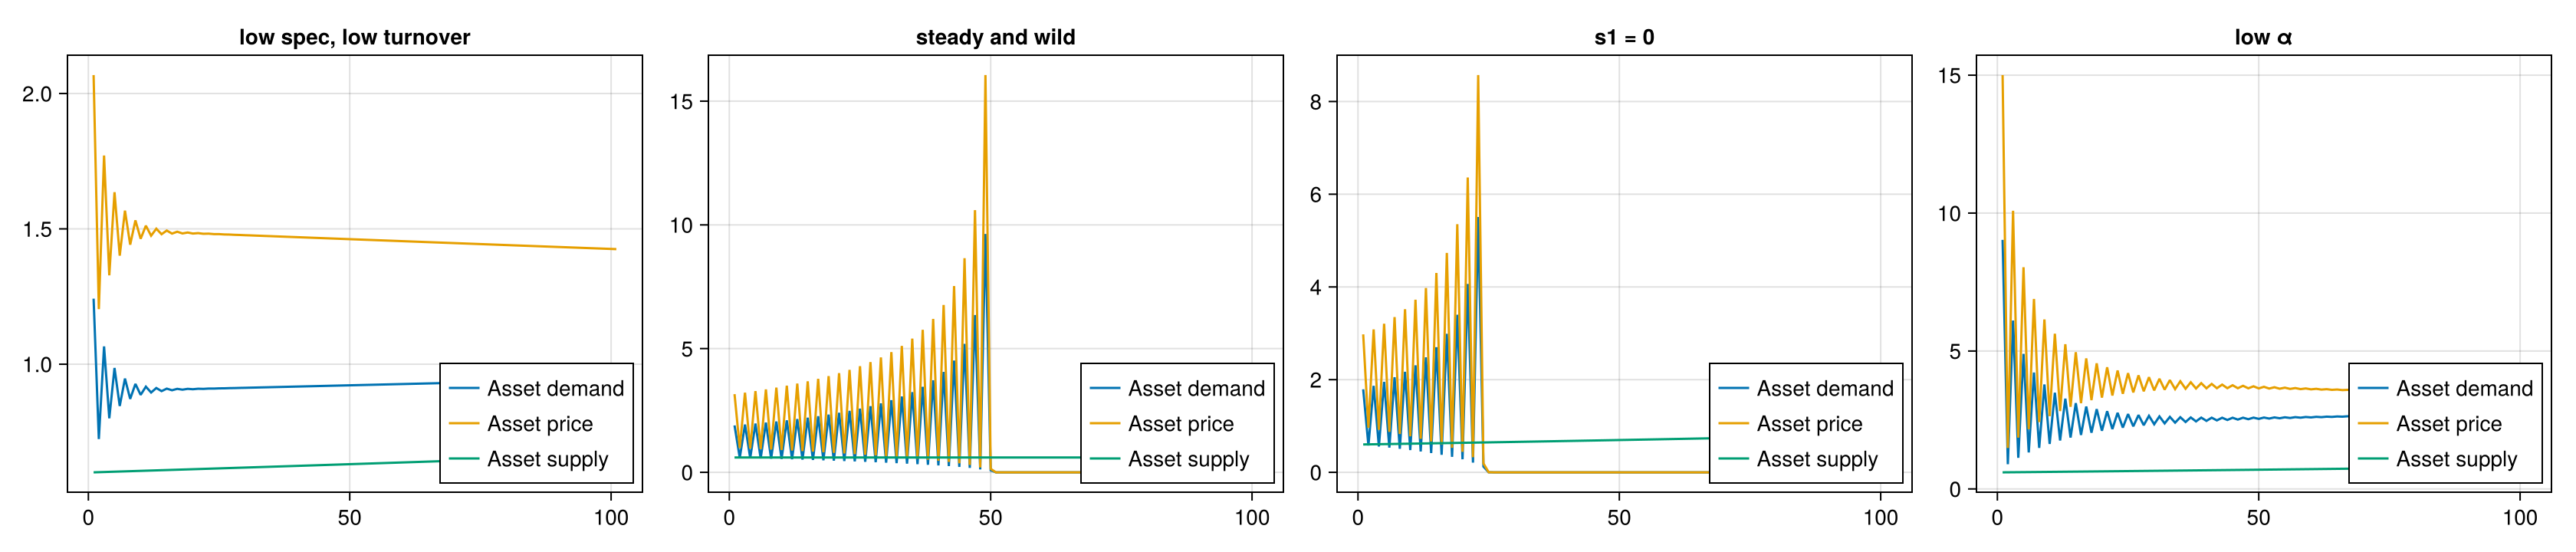

In [26]:
baseline = run_dynq_case()

cases = [
    run_dynq_case(label = "low spec, low turnover", s2_ = 0.8, γ_ = 0.3, gₐ_ = 0.001),
    run_dynq_case(label = "steady and wild", gₐ_ = 0.0, s2_ =0.95),
    run_dynq_case(label = "s1 = 0", s1_ = 1),
    run_dynq_case(label = "low α", γ_ = 0.9),
]

compare_dynq_cases(cases; vars = [:AD, :AP, :AS])

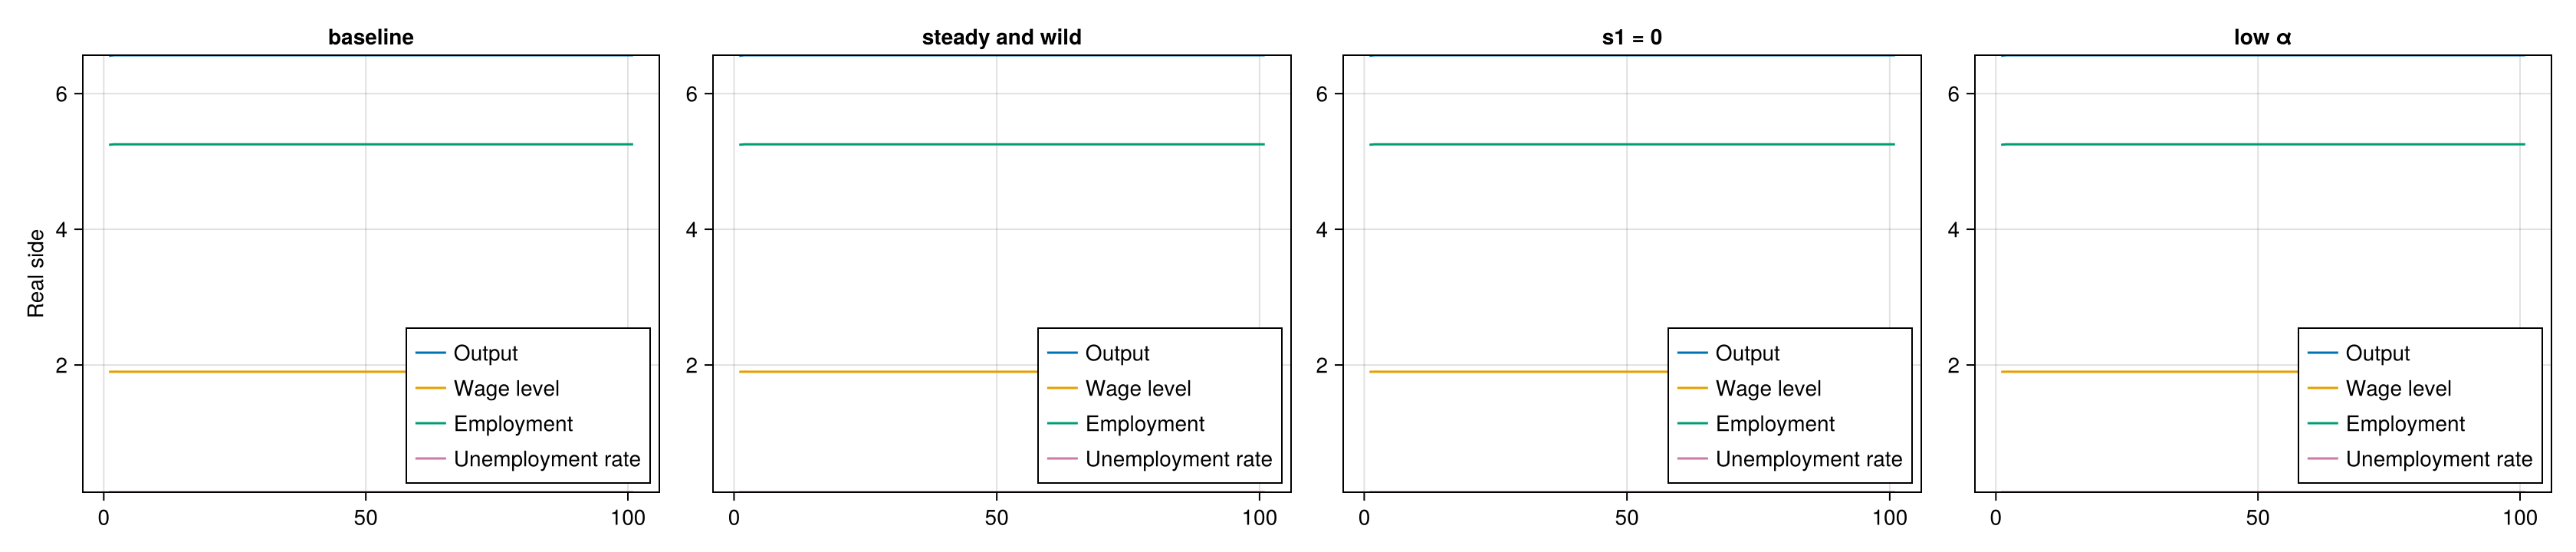

In [23]:
compare_dynq_cases(cases; vars = [:Y, :W, :N, :U], ylabel = "Real side", sharey = true)

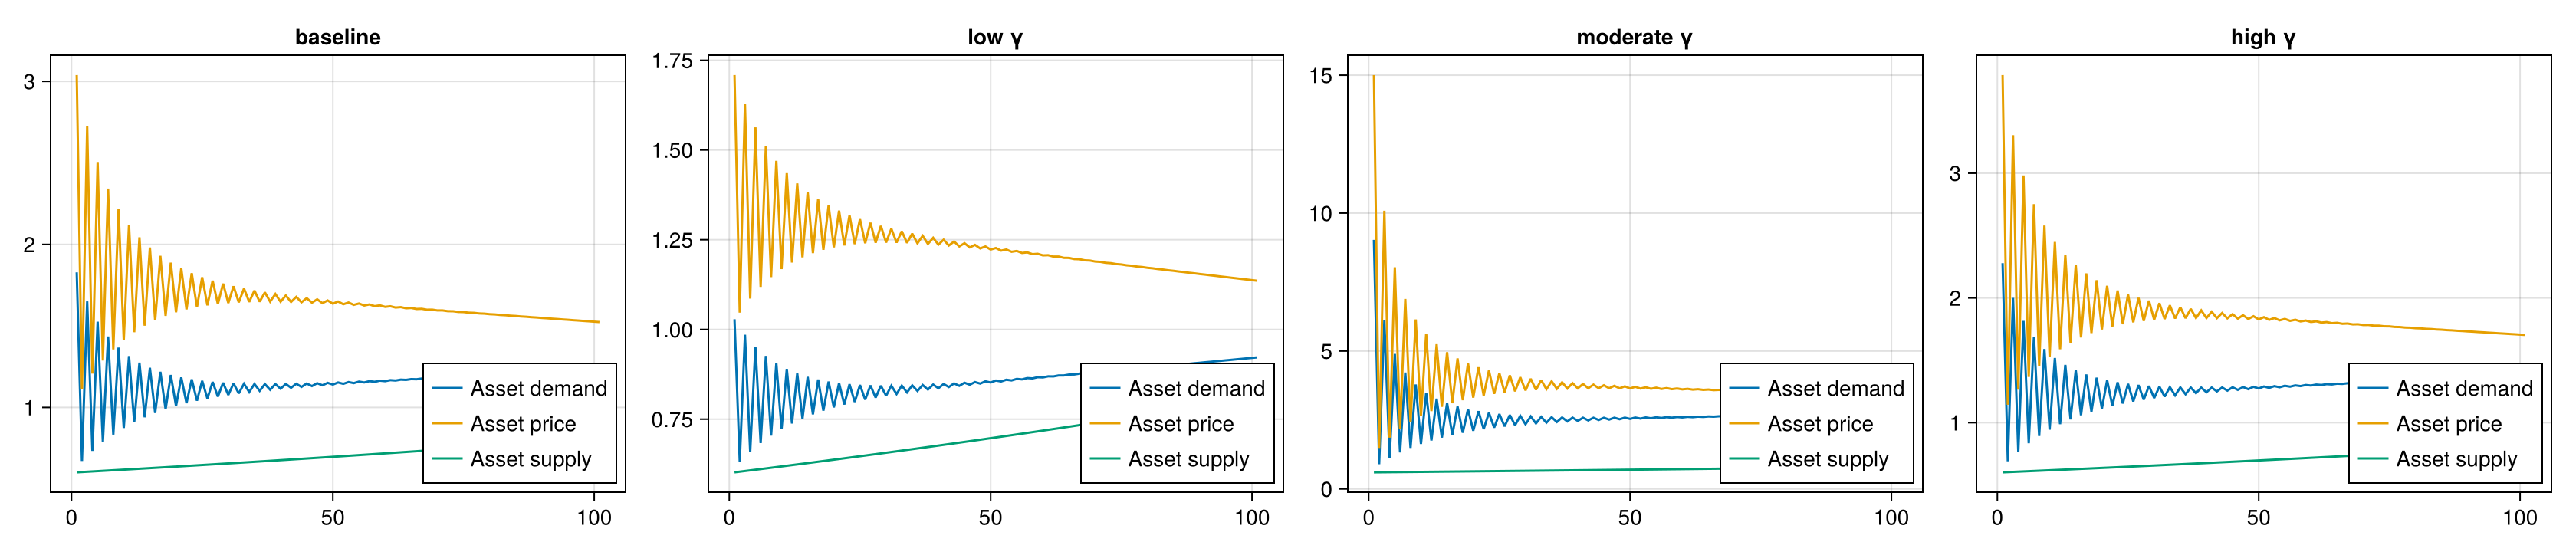

In [32]:
cases = [
    run_dynq_case(label = "baseline"),
    run_dynq_case(label = "low γ", γ_ = 0.1),
    run_dynq_case(label = "moderate γ", s2_=0.9, γ_ = 0.9),
    run_dynq_case(label = "high γ", γ_ = 0.6),
]

compare_dynq_cases(cases; vars = [:AD, :AP, :AS])


(label = "low spec, low turnover", params = (b = 0.5, c = 0.8, d0 = 5.0, d1 = 8.0, i0 = 0.01, i1 = 0.05, m = 0.15, k = 0.3, n = 0.15, W0 = 2.0, h = 0.8, a = 0.8, Nᶠ = 6.0, p1 = 1.0, s0 = 1.0, s1 = 0.5, s2 = 0.2, γ0 = 0.0, γ = 0.3, α = 0.1, gₐ = 0.001), sol = PKAssetPrices.Dynamic.DynamicSolution{PKAssetPrices.Dynamic.var"#77#78", PKAssetPrices.Dynamic.var"#79#80", Float64, Vector{Float64}}(DynamicParametrization{PKAssetPrices.Dynamic.var"#77#78", PKAssetPrices.Dynamic.var"#79#80", Float64, Vector{Float64}}(DynamicModel{PKAssetPrices.Dynamic.var"#77#78", PKAssetPrices.Dynamic.var"#79#80"}(DiscreteTime([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0  …  91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0]), PKAssetPrices.Dynamic.DynVar[PKAssetPrices.Dynamic.DynVar(:Y, "Output"), PKAssetPrices.Dynamic.DynVar(:ND, "Non debt-financed demand"), PKAssetPrices.Dynamic.DynVar(:D, "debt-financed demand"), PKAssetPrices.Dynamic.DynVar(:i, "policy rate"), PKAssetPrices.Dynamic.DynVar(:r,

# Asset market

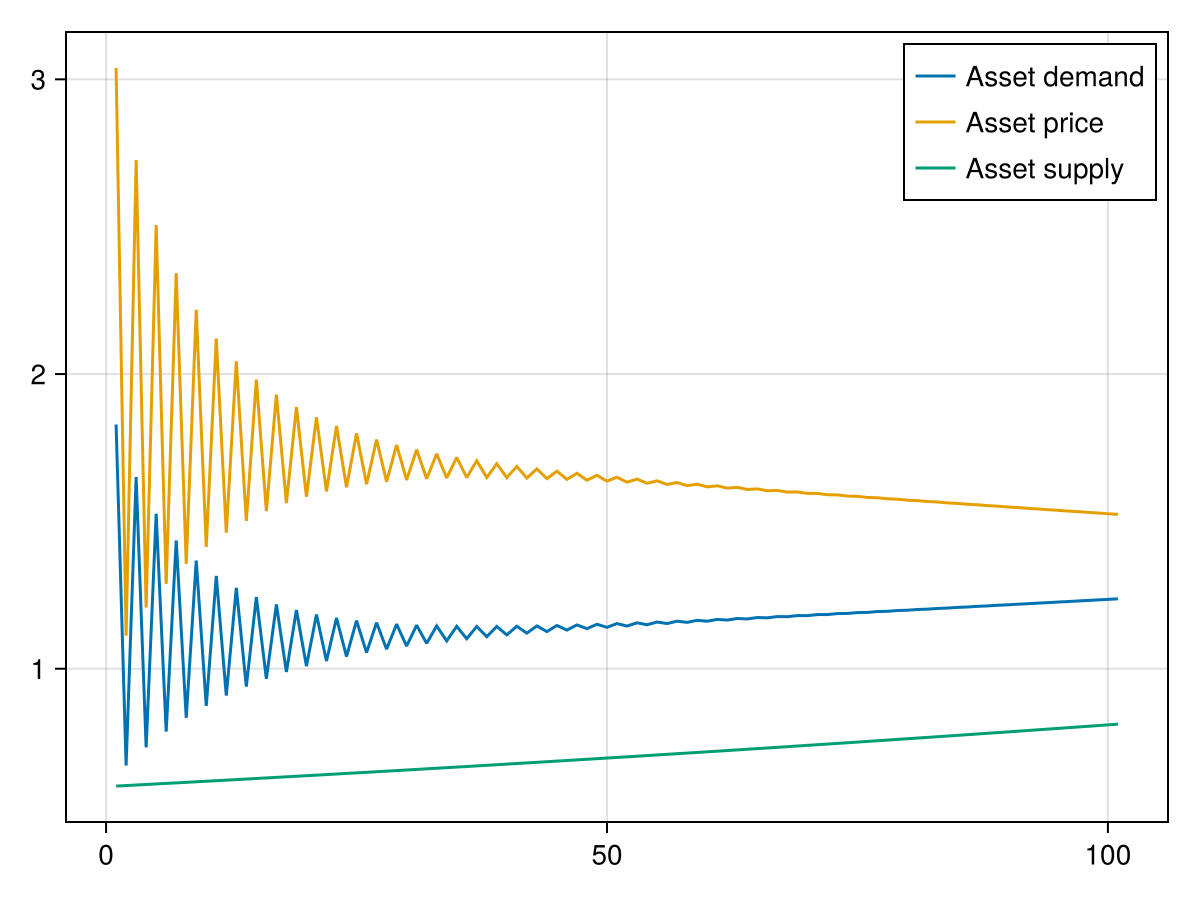

In [13]:

f = Figure()
ax = Axis(f[1,1])
lines!(ax,sol_baseline.paths[:AD], label = "Asset demand")
lines!(ax,sol_baseline.paths[:AP], label = "Asset price")
lines!(ax,sol_baseline.paths[:AS], label = "Asset supply")
axislegend(ax)
f

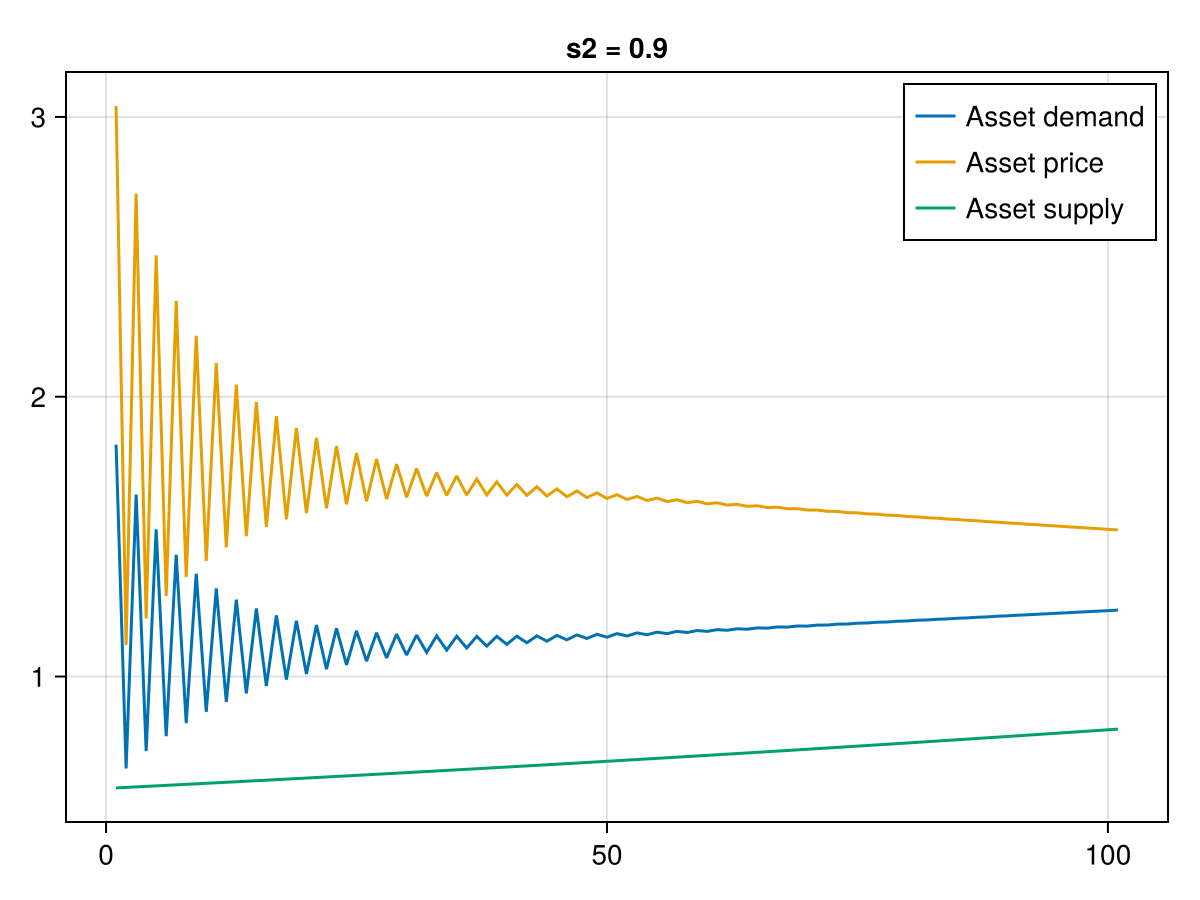

In [14]:
s2_values = range(0.1, 0.9, length = 100)
xs = 1:length(sol_baseline.paths[:AD])

ys_ad = Observable(sol_baseline.paths[:AD])
ys_ap = Observable(sol_baseline.paths[:AP])
ys_as = Observable(sol_baseline.paths[:AS])

f = Figure()
ax = Axis(f[1, 1])
lines!(ax, xs, ys_ad, label = "Asset demand")
lines!(ax, xs, ys_ap, label = "Asset price")
lines!(ax, xs, ys_as, label = "Asset supply")
axislegend(ax)

record(f, "../plots/asset_market_s2_animation.gif", 1:length(s2_values)) do i
    scen = Dynamic.@scenario Dynamic.DynQconAPLevelChange2 begin
         s2 = s2_values[i]
     end
    sol = solve_model(scen)
    ys_ad[] = sol.paths[:AD]
    ys_ap[] = sol.paths[:AP]
    ys_as[] = sol.paths[:AS]
    ax.title = "s2 = $(round(s2_values[i], digits=2))"
end

f

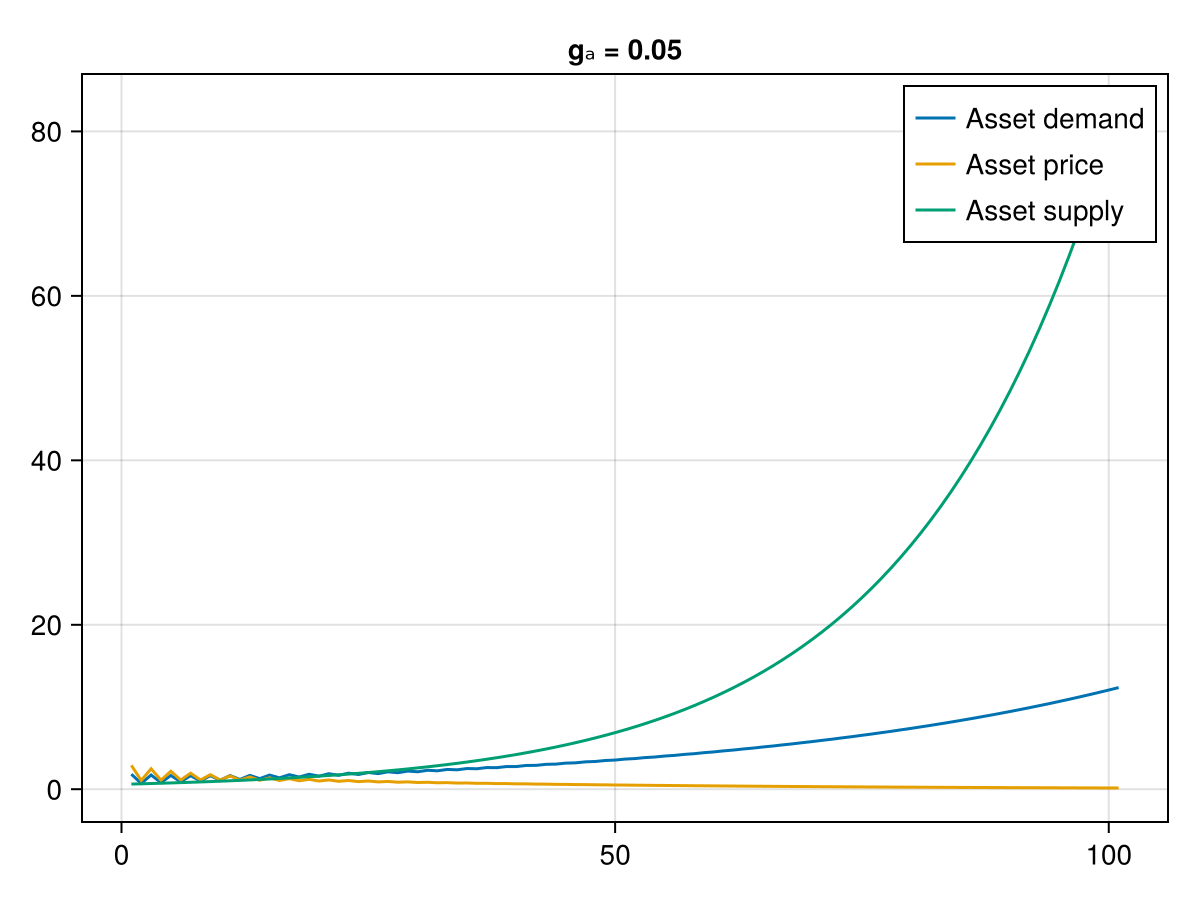

In [17]:
gₐ_values = range(0.0001, 0.05, length = 100)
xs = 1:length(sol_baseline.paths[:AD])

ys_ad = Observable(sol_baseline.paths[:AD])
ys_ap = Observable(sol_baseline.paths[:AP])
ys_as = Observable(sol_baseline.paths[:AS])

f = Figure()
ax = Axis(f[1, 1])
lines!(ax, xs, ys_ad, label = "Asset demand")
lines!(ax, xs, ys_ap, label = "Asset price")
lines!(ax, xs, ys_as, label = "Asset supply")
axislegend(ax)

record(f, "../plots/asset_market_gₐ_animation.gif", 1:length(gₐ_values)) do i
    scen = Dynamic.@scenario Dynamic.DynQconAPLevelChange2 begin
         gₐ = gₐ_values[i]
     end
    sol = solve_model(scen)
    ys_ad[] = sol.paths[:AD]
    ys_ap[] = sol.paths[:AP]
    ys_as[] = sol.paths[:AS]
    ax.title = "gₐ = $(round(gₐ_values[i], digits=4))"
end

f

# Real economy


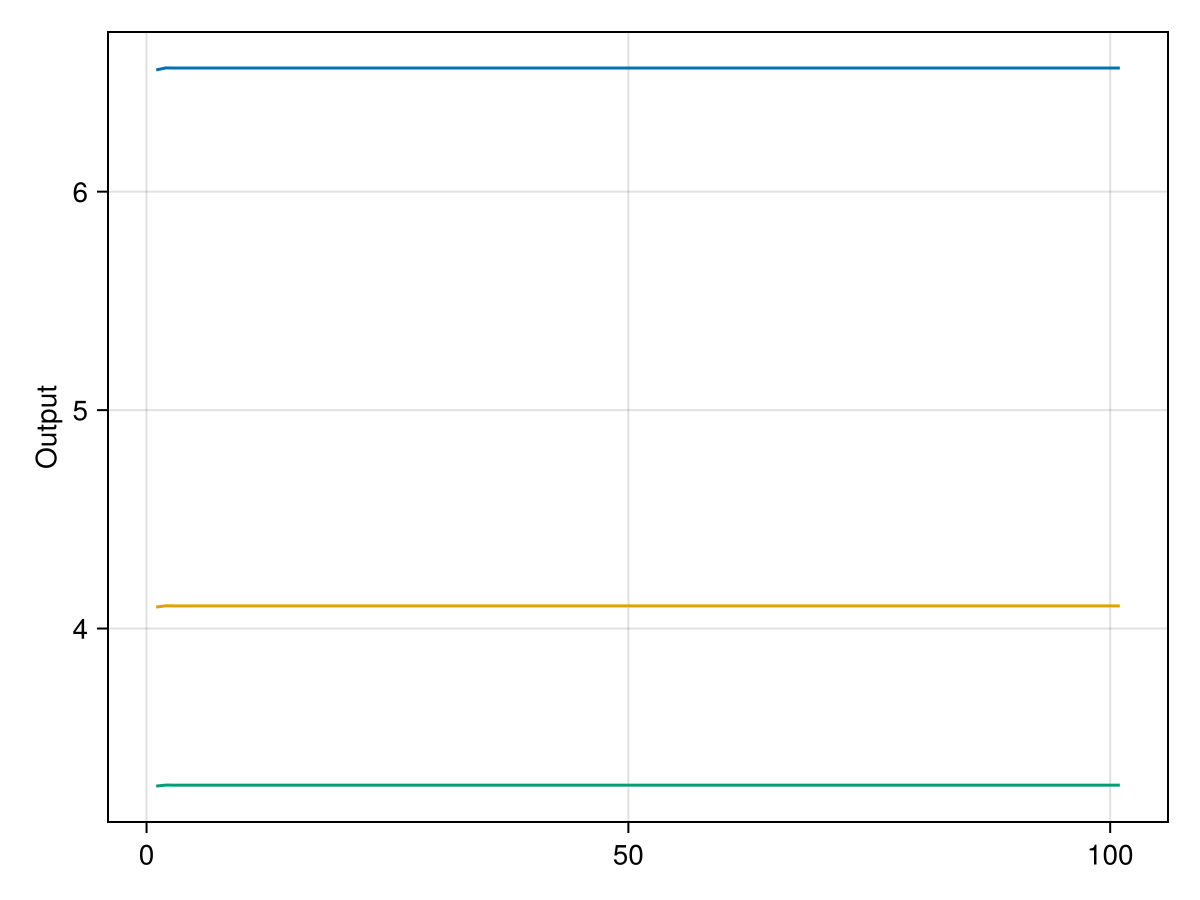

In [15]:
f = Figure()
ax = Axis(f[1,1], ylabel = "Output")

lines!(ax,sol_baseline.paths[:Y], label = "GDP")
lines!(ax,sol_baseline.paths[:D], label = "Debt financed demand")
lines!(ax,sol_baseline.paths[:ND], label = "Non-debt financed deman")
f

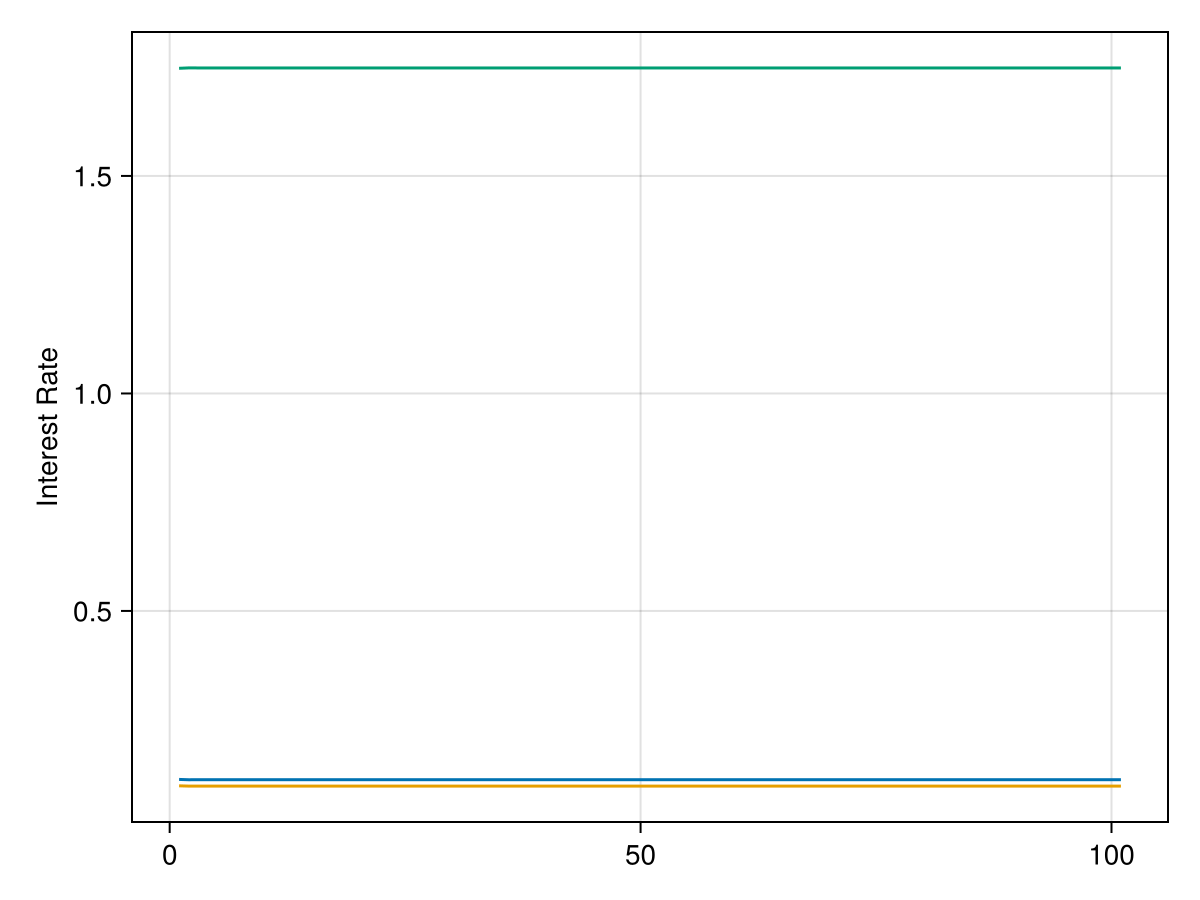

In [ ]:
f = Figure()
ax = Axis(f[1,1], ylabel = "Interest Rate")

lines!(ax,sol_baseline.paths[:r], label = "Interest rate")
lines!(ax,sol_baseline.paths[:i], label = "Policy rate")
lines!(ax,sol_baseline.paths[:P], label = "Prices")
f

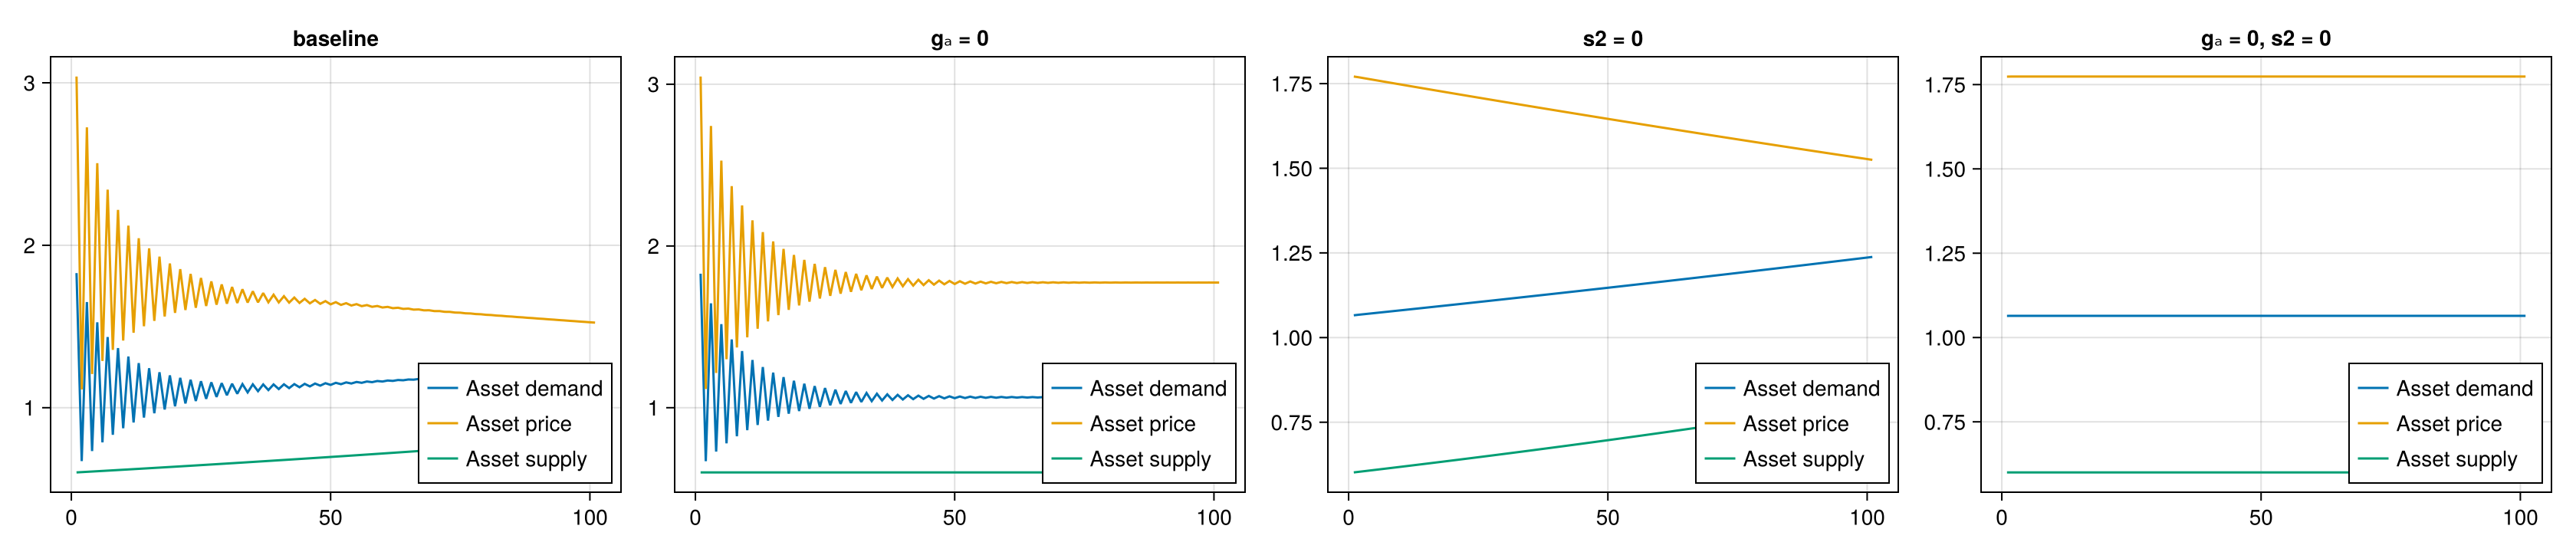

In [16]:
# Helper functions for parameter experiments on Dynamic.DynQconAPLevelChange2

function run_dynq_case(;
    label = "baseline",
    b_ = 0.5, c_ = 0.8, d0_ = 5.0, d1_ = 8.0,
    i0_ = 0.01, i1_ = 0.05, m_ = 0.15, k_ = 0.3,
    n_ = 0.15, W0_ = 2.0, h_ = 0.8, a_ = 0.8, Nf_ = 6.0,
    p1_ = 1.0, s0_ = 1.0, s1_ = 0.5, s2_ = 0.9,
    γ0_ = 0.0, γ_ = 0.5, α_ = 0.1, gₐ_ = 0.003
)

    scen = Dynamic.@scenario Dynamic.DynQconAPLevelChange2 begin
        b  = b_
        c  = c_
        d0 = d0_
        d1 = d1_
        i0 = i0_
        i1 = i1_
        m  = m_
        k  = k_
        n  = n_
        W0 = W0_
        h  = h_
        a  = a_
        Nᶠ = Nf_
        p1 = p1_
        s0 = s0_
        s1 = s1_
        s2 = s2_
        γ0 = γ0_
        γ  = γ_
        α  = α_
        gₐ = gₐ_
    end

    sol = solve_model(scen)

    params = (
        b = b_, c = c_, d0 = d0_, d1 = d1_,
        i0 = i0_, i1 = i1_, m = m_, k = k_,
        n = n_, W0 = W0_, h = h_, a = a_, Nᶠ = Nf_,
        p1 = p1_, s0 = s0_, s1 = s1_, s2 = s2_,
        γ0 = γ0_, γ = γ_, α = α_, gₐ = gₐ_
    )

    return (; label, params, sol)
end

function compare_dynq_cases(cases;
    vars = [:AD, :AP, :AS],
    figure_size = (420 * length(cases), 360),
    legend_position = :rb,
    ylabel = "",
    sharey = false
)
    f = Figure(size = figure_size)

    pretty = Dict(
        :AD => "Asset demand",
        :AP => "Asset price",
        :AS => "Asset supply",
        :SD => "Speculative debt",
        :AQ => "Asset amount",
        :Y  => "Output",
        :D  => "Debt financed demand",
        :ND => "Non-debt financed demand",
        :r  => "Interest rate",
        :i  => "Policy rate",
        :P  => "Price level",
        :W  => "Wage level",
        :N  => "Employment",
        :U  => "Unemployment rate"
    )

    axes = Axis[]

    for (idx, case) in enumerate(cases)
        ax = Axis(f[1, idx], title = case.label, ylabel = idx == 1 ? ylabel : "")
        push!(axes, ax)
        for v in vars
            lines!(ax, case.sol.paths[v], label = get(pretty, v, String(v)))
        end
        axislegend(ax, position = legend_position)
    end

    if sharey && !isempty(axes)
        ylims_all = [extrema(case.sol.paths[v]) for case in cases for v in vars]
        ymin = minimum(first, ylims_all)
        ymax = maximum(last, ylims_all)
        for ax in axes
            ylims!(ax, ymin, ymax)
        end
    end

    return f
end

function compare_dynq_real_cases(cases;
    figure_size = (420 * length(cases), 360),
    legend_position = :rb,
    ylabel = "Output",
    sharey = false
)
    return compare_dynq_cases(
        cases;
        vars = [:Y, :D, :ND],
        figure_size = figure_size,
        legend_position = legend_position,
        ylabel = ylabel,
        sharey = sharey
    )
end


baseline_case = run_dynq_case()

steady_state_probe_cases = [
    baseline_case,
    run_dynq_case(label = "gₐ = 0", gₐ_ = 0.0),
    run_dynq_case(label = "s2 = 0", s2_ = 0.0),
    run_dynq_case(label = "gₐ = 0, s2 = 0", gₐ_ = 0.0, s2_ = 0.0),
]

compare_dynq_cases(steady_state_probe_cases)
